In [5]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()
url = os.getenv("DB_URL")

engine = create_engine(url)

In [7]:
import pandas as pd
orders_df = pd.read_sql_table("orders", engine)
orders_df.head(1)

,id,ticker,class_code,timestamp,side,volume,price,quantity
0,1,SR330CD6A,OPTSPOT,2026-03-23 15:59:24+00:00,BUY,1,0,1


In [8]:
orders_df['timestamp'] = pd.to_datetime(orders_df['timestamp'])
orders_df.set_index('timestamp', inplace=True)
orders_df.sort_index(inplace=True)
orders_df['strike'] = orders_df['ticker'].astype(str).str[2:5]

orders_df.head(1)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-03-23 15:59:24+00:00,1,SR330CD6A,OPTSPOT,BUY,1,0,1,330


In [41]:
large_buy_orders = orders_df[orders_df['side'] == "BUY"].sort_values(by='volume', ascending=False).head(1000)
large_buy_orders.head(5)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310
2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340
2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310
2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310
2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320


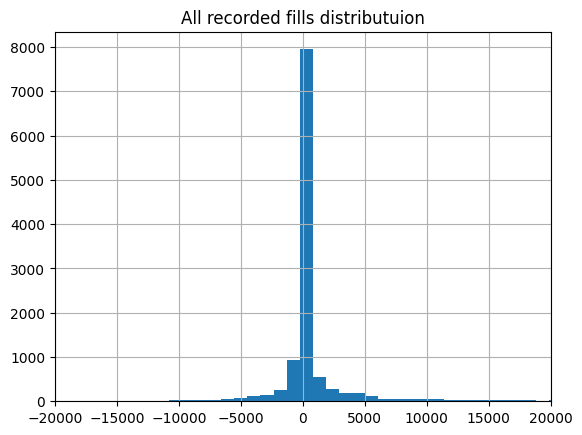

count     11582.000000
mean        458.266966
std        5172.764186
min     -270000.000000
25%         -45.000000
50%          11.000000
75%         240.000000
max      153143.000000
Name: volume, dtype: float64

In [42]:
from matplotlib import pyplot as plt 
hist_df = orders_df.copy()
hist_df.loc[hist_df['side'] == "SELL", 'volume'] *= -1

plt.hist(hist_df['volume'], bins=400)
plt.xlim(-20000, 20000)
plt.grid()
plt.title("All recorded fills distributuion")
plt.show()

hist_df['volume'].describe()

In [11]:
engine = create_engine(url)

orderbooks_df = pd.read_sql("orderbooks", engine)
orderbooks_df.head(1)

,id,ticker,class_code,timestamp,bids,asks,bid_volume,ask_volume
0,959197,SR320CE6A,OPTSPOT,2026-05-04 15:18:06+00:00,"[{'price': 1.33, 'quantity': 800}, {'price': 1...","[{'price': 1.68, 'quantity': 4000}, {'price': ...",136517,11968


In [12]:
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.sort_index(inplace=True)
orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume
timestamp,,,,,,,
2026-03-23 15:39:07+00:00,32065,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1


In [13]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['mid'] = (orderbooks_df['best_ask'] + orderbooks_df['best_bid'])/2

orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume,best_bid,best_ask,mid
timestamp,,,,,,,,,,
2026-03-23 15:39:07+00:00,32065,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1,NaN,0.54,NaN


In [43]:
large_buy_orders['ts_adj'] = large_buy_orders.index + pd.Timedelta(microseconds=1)
df = pd.merge_asof(
    large_buy_orders.reset_index().sort_values('ts_adj'), 
    orderbooks_df[['ticker', 'best_bid', 'best_ask', 'mid']].reset_index(),
    left_on='ts_adj', 
    right_on = 'timestamp',
    by='ticker',
    direction='forward')

df.sort_values("volume", ascending=False).head()

,timestamp_x,id,ticker,class_code,side,volume,price,quantity,strike,ts_adj,timestamp_y,best_bid,best_ask,mid
205,2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310,2026-04-01 10:56:46.000001+00:00,2026-04-01 10:58:55+00:00,8.19,8.50,8.345
945,2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340,2026-05-06 13:48:07.000001+00:00,2026-05-06 13:48:12+00:00,16.25,17.99,17.120
31,2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310,2026-03-25 11:46:13.000001+00:00,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
22,2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310,2026-03-25 06:19:33.000001+00:00,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
749,2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320,2026-04-24 19:06:47.000001+00:00,2026-04-24 19:06:48+00:00,8.20,8.78,8.490


In [44]:
df = df[['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'timestamp_y', 'best_bid', 'best_ask', 'mid']]
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid
0,2026-03-23 18:41:07+00:00,SR310CD6,6465,12,310,2026-03-23 18:41:08+00:00,11.81,12.93,12.37
1,2026-03-23 20:19:26+00:00,SR320CP6,3300,5,320,2026-03-23 20:22:41+00:00,5.00,5.50,5.25
2,2026-03-23 20:23:12+00:00,SR320CP6,4950,5,320,2026-03-23 20:23:13+00:00,5.00,5.50,5.25
3,2026-03-24 06:43:23+00:00,SR310CD6A,3940,9,310,2026-03-24 06:43:24+00:00,7.99,9.85,8.92
4,2026-03-24 07:28:47+00:00,SR300CD6A,3618,18,300,2026-03-24 07:28:48+00:00,17.88,18.50,18.19


In [45]:
horizons = [5, 30, 60, 120, 480, 720, 1440, 4320, 10080] #minues
for h in horizons:
    df['time_adj'] = df['timestamp_y'] + pd.Timedelta(minutes=h)
    merged = pd.merge_asof(
        df.sort_values('time_adj'),
        orderbooks_df.reset_index(),
        left_on = 'time_adj',
        right_on = 'timestamp',
        direction = 'nearest',
        tolerance = pd.Timedelta(minutes = h/2),
        by = 'ticker'
    ).sort_index() 
    df[f'best_ask_{h}'] = merged['best_ask_y']
    df[f'best_bid_{h}'] = merged['best_bid_y']
    df[f'mid_{h}'] = merged['mid_y']
    
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid,time_adj,...,mid_720,best_ask_1440,best_bid_1440,mid_1440,best_ask_4320,best_bid_4320,mid_4320,best_ask_10080,best_bid_10080,mid_10080
0,2026-03-23 18:41:07+00:00,SR310CD6,6465,12,310,2026-03-23 18:41:08+00:00,11.81,12.93,12.37,2026-03-30 18:41:08+00:00,...,12.205,12.10,12.00,12.050,11.26,9.36,10.310,9.34,8.18,8.760
1,2026-03-23 20:19:26+00:00,SR320CP6,3300,5,320,2026-03-23 20:22:41+00:00,5.00,5.50,5.25,2026-03-30 20:22:41+00:00,...,5.575,5.89,5.00,5.445,6.46,5.96,6.210,6.51,5.54,6.025
2,2026-03-23 20:23:12+00:00,SR320CP6,4950,5,320,2026-03-23 20:23:13+00:00,5.00,5.50,5.25,2026-03-30 20:23:13+00:00,...,5.575,5.89,5.00,5.445,6.46,5.96,6.210,6.51,5.54,6.025
3,2026-03-24 06:43:23+00:00,SR310CD6A,3940,9,310,2026-03-24 06:43:24+00:00,7.99,9.85,8.92,2026-03-31 06:43:24+00:00,...,8.770,9.88,9.02,9.450,7.57,7.07,7.320,5.63,4.87,5.250
4,2026-03-24 07:28:47+00:00,SR300CD6A,3618,18,300,2026-03-24 07:28:48+00:00,17.88,18.50,18.19,2026-03-31 07:28:48+00:00,...,18.960,18.87,18.55,18.710,16.63,16.60,16.615,14.37,14.03,14.200


In [46]:
for h in horizons:
    df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']

In [52]:
filtered_df = df.loc[df['strike'].astype(int) > 340]

snr_not_filtered = []
snr_filtered = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'] 
    filtered_returns = df.loc[df['strike'].astype(int) > 330][f'mid_price_return_{h}']

    print(f"h = {h}, count = {len(returns)}")
    mean = returns.mean()
    std = returns.std()
    snr_not_filtered.append(mean/std)

    mean = filtered_returns.mean()
    std = filtered_returns.std()
    snr_filtered.append(mean/std)

h = 5, count = 1000
h = 30, count = 1000
h = 60, count = 1000
h = 120, count = 1000
h = 480, count = 1000
h = 720, count = 1000
h = 1440, count = 1000
h = 4320, count = 1000
h = 10080, count = 1000


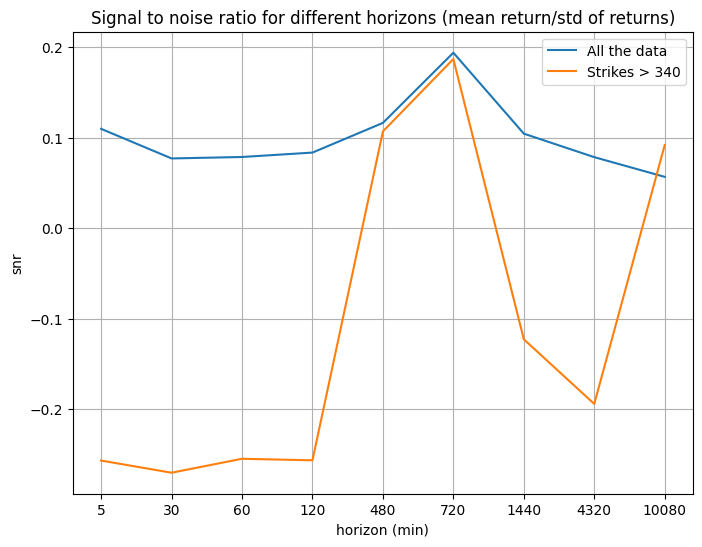

In [51]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), snr_not_filtered, label="All the data")
plt.plot(range(len(horizons)), snr_filtered, label="Strikes > 340")
plt.xticks(range(len(horizons)), horizons)
plt.grid()
plt.title("Signal to noise ratio for different horizons (mean return/std of returns)")
plt.xlabel("horizon (min)")
plt.ylabel("snr")
plt.legend()
plt.show()